In [2]:
import numpy as np


In [3]:
data = np.load(r"C:\Users\ASUS\Downloads\PEMS08.npz\PEMS08.npz")

In [4]:
print(data.files)

['data']


In [5]:
arr=data['data']
print(arr)

[[[1.330e+02 6.030e-02 6.580e+01]
  [2.100e+02 5.890e-02 6.960e+01]
  [1.240e+02 3.580e-02 6.580e+01]
  ...
  [7.400e+01 2.131e-01 6.530e+01]
  [9.400e+01 2.260e-02 6.800e+01]
  [6.000e+00 3.100e-03 6.500e+01]]

 [[1.140e+02 5.320e-02 6.690e+01]
  [1.850e+02 5.500e-02 6.850e+01]
  [1.190e+02 3.390e-02 6.500e+01]
  ...
  [7.300e+01 1.469e-01 3.720e+01]
  [8.400e+01 1.890e-02 6.870e+01]
  [4.000e+00 1.800e-03 6.500e+01]]

 [[1.400e+02 6.220e-02 6.680e+01]
  [1.710e+02 4.660e-02 6.990e+01]
  [1.070e+02 3.360e-02 6.380e+01]
  ...
  [7.000e+01 5.860e-02 3.400e+01]
  [8.200e+01 2.200e-02 6.700e+01]
  [4.000e+00 2.100e-03 6.490e+01]]

 ...

 [[1.200e+02 5.810e-02 6.330e+01]
  [1.760e+02 5.290e-02 6.680e+01]
  [1.190e+02 5.180e-02 5.610e+01]
  ...
  [4.700e+01 1.551e-01 3.220e+01]
  [9.100e+01 2.290e-02 6.640e+01]
  [3.000e+00 1.400e-03 6.530e+01]]

 [[1.020e+02 5.790e-02 6.140e+01]
  [1.650e+02 4.920e-02 6.720e+01]
  [1.330e+02 5.070e-02 5.890e+01]
  ...
  [9.700e+01 1.265e-01 3.080e+01]
  [8

In [6]:
print(arr.shape)

(17856, 170, 3)


In [37]:
import pandas as pd

df = pd.DataFrame(arr.reshape(arr.shape[0], -1))
print(df.shape)
print(df.head())


(17856, 510)
     0       1     2      3       4     5      6       7     8      9    ...  \
0  133.0  0.0603  65.8  210.0  0.0589  69.6  124.0  0.0358  65.8  145.0  ...   
1  114.0  0.0532  66.9  185.0  0.0550  68.5  119.0  0.0339  65.0  184.0  ...   
2  140.0  0.0622  66.8  171.0  0.0466  69.9  107.0  0.0336  63.8  146.0  ...   
3  106.0  0.0452  68.9  174.0  0.0529  68.0   98.0  0.0326  63.5  148.0  ...   
4  117.0  0.0574  67.4  176.0  0.0484  68.7  114.0  0.0348  63.1  130.0  ...   

    500   501     502   503    504     505   506  507     508   509  
0  69.3  74.0  0.2131  65.3   94.0  0.0226  68.0  6.0  0.0031  65.0  
1  68.6  73.0  0.1469  37.2   84.0  0.0189  68.7  4.0  0.0018  65.0  
2  68.8  70.0  0.0586  34.0   82.0  0.0220  67.0  4.0  0.0021  64.9  
3  68.2  66.0  0.0324  40.7  103.0  0.0251  67.5  2.0  0.0010  64.9  
4  67.9  60.0  0.0161  58.5   86.0  0.0212  67.1  6.0  0.0031  64.9  

[5 rows x 510 columns]


In [8]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

arr = data['data']   # shape (17856,170,3)

# we predict traffic flow (feature 0)
flow = arr[:,:,0]

SEQ_LEN = 12
PRED_LEN = 1

X=[]
Y=[]

for i in range(len(flow)-SEQ_LEN-PRED_LEN):
    X.append(flow[i:i+SEQ_LEN])
    Y.append(flow[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN])

X=np.array(X)
Y=np.array(Y)

# train test split
split=int(0.8*len(X))
X_train,X_test = X[:split],X[split:]
Y_train,Y_test = Y[:split],Y[split:]


In [9]:
class TrafficDataset(Dataset):
    def __init__(self,X,Y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.Y=torch.tensor(Y,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx],self.Y[idx]

train_loader=DataLoader(TrafficDataset(X_train,Y_train),batch_size=64,shuffle=True)
test_loader=DataLoader(TrafficDataset(X_test,Y_test),batch_size=64)


In [10]:
import torch.nn as nn

class CNNTransformer(nn.Module):
    def __init__(self,sensors=170):
        super().__init__()

        # CNN spatial encoder
        self.cnn = nn.Conv1d(in_channels=sensors,out_channels=128,kernel_size=3,padding=1)

        # Transformer (LLM-like)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=8,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,num_layers=2)

        self.fc = nn.Linear(128,sensors)

    def forward(self,x):
        # x (B,SEQ,SENSOR)
        x = x.permute(0,2,1)      # (B,SENSOR,SEQ)
        x = self.cnn(x)           # (B,128,SEQ)
        x = x.permute(0,2,1)      # (B,SEQ,128)

        x = self.transformer(x)

        x = self.fc(x[:,-1,:])    # last timestep
        return x.unsqueeze(1)


In [11]:
device="cuda" if torch.cuda.is_available() else "cpu"

model=CNNTransformer().to(device)

# reduced learning rate
optimizer=torch.optim.Adam(model.parameters(),lr=0.0003)

criterion=nn.MSELoss()

EPOCHS = 40

for epoch in range(EPOCHS):
    model.train()
    loss_total=0

    for x,y in train_loader:
        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()
        pred=model(x)

        loss=criterion(pred,y)
        loss.backward()

        # gradient clipping improves stability
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

        optimizer.step()

        loss_total+=loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss {loss_total/len(train_loader):.4f}")


Epoch 1/40, Loss 72244.6811
Epoch 2/40, Loss 67526.2473
Epoch 3/40, Loss 62851.0111
Epoch 4/40, Loss 57836.6576
Epoch 5/40, Loss 52437.2543
Epoch 6/40, Loss 47065.0192
Epoch 7/40, Loss 41364.5605
Epoch 8/40, Loss 35854.7993
Epoch 9/40, Loss 30595.9708
Epoch 10/40, Loss 25563.5806
Epoch 11/40, Loss 21133.3240
Epoch 12/40, Loss 17028.7617
Epoch 13/40, Loss 13548.2768
Epoch 14/40, Loss 10823.4056
Epoch 15/40, Loss 8475.0781
Epoch 16/40, Loss 6891.8881
Epoch 17/40, Loss 5566.8471
Epoch 18/40, Loss 4613.6071
Epoch 19/40, Loss 4010.7084
Epoch 20/40, Loss 3587.8092
Epoch 21/40, Loss 3267.0285
Epoch 22/40, Loss 3038.2949
Epoch 23/40, Loss 2884.3236
Epoch 24/40, Loss 2752.4388
Epoch 25/40, Loss 2629.5497
Epoch 26/40, Loss 2507.6796
Epoch 27/40, Loss 2404.1597
Epoch 28/40, Loss 2317.9237
Epoch 29/40, Loss 2237.6155
Epoch 30/40, Loss 2170.3030
Epoch 31/40, Loss 2098.1855
Epoch 32/40, Loss 2033.3664
Epoch 33/40, Loss 1966.0600
Epoch 34/40, Loss 1901.7844
Epoch 35/40, Loss 1850.9767
Epoch 36/40, Lo

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()
preds=[]
true=[]

with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device)
        pred=model(x).cpu().numpy()
        preds.append(pred)
        true.append(y.numpy())

preds=np.concatenate(preds)
true=np.concatenate(true)

rmse = np.sqrt(mean_squared_error(true.flatten(),preds.flatten()))
mae = mean_absolute_error(true.flatten(),preds.flatten())

print("RMSE:",rmse)
print("MAE:",mae)


RMSE: 39.06768403101053
MAE: 26.62078094482422


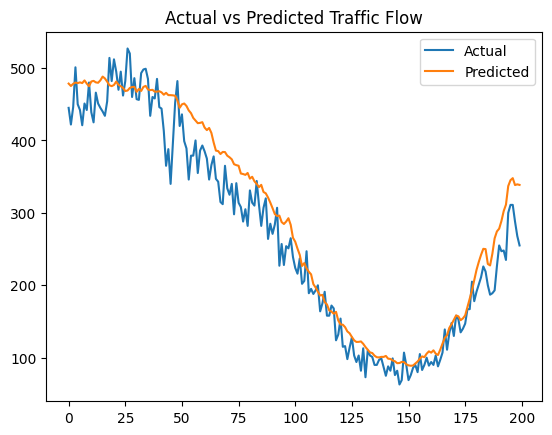

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(true[:200,0,0],label="Actual")
plt.plot(preds[:200,0,0],label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Traffic Flow")
plt.show()


In [14]:
import numpy as np
import torch

arr = data['data']          # (17856,170,3)

flow = arr[:,:,0]

mean = flow.mean()
std  = flow.std()

flow = (flow - mean)/std


In [15]:
SEQ_LEN = 24
PRED_LEN = 1

X=[]
Y=[]

for i in range(len(flow)-SEQ_LEN-PRED_LEN):
    X.append(flow[i:i+SEQ_LEN])
    Y.append(flow[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN])

X=np.array(X)
Y=np.array(Y)

split=int(0.8*len(X))
X_train,X_test = X[:split],X[split:]
Y_train,Y_test = Y[:split],Y[split:]


In [16]:
from torch.utils.data import Dataset,DataLoader

class TrafficDataset(Dataset):
    def __init__(self,X,Y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.Y=torch.tensor(Y,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx],self.Y[idx]

train_loader=DataLoader(TrafficDataset(X_train,Y_train),batch_size=64,shuffle=True)
test_loader=DataLoader(TrafficDataset(X_test,Y_test),batch_size=64)


In [17]:
import torch.nn as nn

class CNNTransformer(nn.Module):
    def __init__(self,sensors=170):
        super().__init__()

        # stronger CNN
        self.cnn = nn.Sequential(
            nn.Conv1d(sensors,128,3,padding=1),
            nn.ReLU(),
            nn.Conv1d(128,128,3,padding=1),
            nn.ReLU()
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=8,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer,num_layers=3)

        self.fc = nn.Linear(128,sensors)

    def forward(self,x):
        # (B,SEQ,SENSOR)
        x=x.permute(0,2,1)
        x=self.cnn(x)
        x=x.permute(0,2,1)

        x=self.transformer(x)

        x=self.fc(x[:,-1,:])
        return x.unsqueeze(1)


In [18]:
device="cuda" if torch.cuda.is_available() else "cpu"

model=CNNTransformer().to(device)

optimizer=torch.optim.Adam(model.parameters(),lr=0.0002)
criterion=nn.MSELoss()

for epoch in range(40):
    model.train()
    total=0

    for x,y in train_loader:
        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()
        pred=model(x)
        loss=criterion(pred,y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()

        total+=loss.item()

    print("epoch",epoch,"loss",total/len(train_loader))


epoch 0 loss 0.1476440663896334
epoch 1 loss 0.05205138929756233
epoch 2 loss 0.04129762426352822
epoch 3 loss 0.03615976884259504
epoch 4 loss 0.03310901998237377
epoch 5 loss 0.031046032120427742
epoch 6 loss 0.02934734817310299
epoch 7 loss 0.02824021268619283
epoch 8 loss 0.027208855342236868
epoch 9 loss 0.026513014523304096
epoch 10 loss 0.0258567503532353
epoch 11 loss 0.025316959088292356
epoch 12 loss 0.024764178830278295
epoch 13 loss 0.02439086566858762
epoch 14 loss 0.02390420992311608
epoch 15 loss 0.02358822161206483
epoch 16 loss 0.023207487337992865
epoch 17 loss 0.023016815470539936
epoch 18 loss 0.022652257025041388
epoch 19 loss 0.02246496345296569
epoch 20 loss 0.022156304241295888
epoch 21 loss 0.02193131268592426
epoch 22 loss 0.02164246083441871
epoch 23 loss 0.0215381880462036
epoch 24 loss 0.02130738520501975
epoch 25 loss 0.021182669009261603
epoch 26 loss 0.020924479855149315
epoch 27 loss 0.02074652373991205
epoch 28 loss 0.0205728112481902
epoch 29 loss 0.0

In [19]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

model.eval()
preds=[]
true=[]

with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device)
        p=model(x).cpu().numpy()
        preds.append(p)
        true.append(y.numpy())

preds=np.concatenate(preds)
true=np.concatenate(true)

# denormalize
preds = preds*std + mean
true  = true*std + mean

rmse=np.sqrt(mean_squared_error(true.flatten(),preds.flatten()))
mae=mean_absolute_error(true.flatten(),preds.flatten())

print("RMSE:",rmse)
print("MAE:",mae)


RMSE: 25.146081671518335
MAE: 16.570306750882985


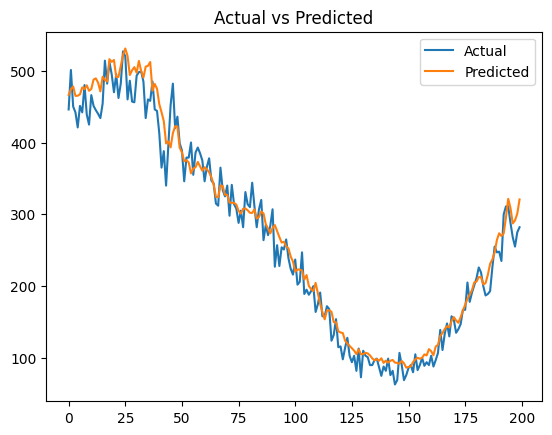

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(true[:200,0,0],label="Actual")
plt.plot(preds[:200,0,0],label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()


In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNNTransformer().to(device)

# lower learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.00012)

criterion = nn.MSELoss()

EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)
        loss.backward()

        # gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.5f}")


Epoch 1/100, Loss: 0.18552
Epoch 2/100, Loss: 0.05889
Epoch 3/100, Loss: 0.04705
Epoch 4/100, Loss: 0.04091
Epoch 5/100, Loss: 0.03709
Epoch 6/100, Loss: 0.03449
Epoch 7/100, Loss: 0.03254
Epoch 8/100, Loss: 0.03101
Epoch 9/100, Loss: 0.02993
Epoch 10/100, Loss: 0.02889
Epoch 11/100, Loss: 0.02805
Epoch 12/100, Loss: 0.02727
Epoch 13/100, Loss: 0.02670
Epoch 14/100, Loss: 0.02620
Epoch 15/100, Loss: 0.02562
Epoch 16/100, Loss: 0.02526
Epoch 17/100, Loss: 0.02487
Epoch 18/100, Loss: 0.02449
Epoch 19/100, Loss: 0.02418
Epoch 20/100, Loss: 0.02385
Epoch 21/100, Loss: 0.02356
Epoch 22/100, Loss: 0.02325
Epoch 23/100, Loss: 0.02311
Epoch 24/100, Loss: 0.02285
Epoch 25/100, Loss: 0.02259
Epoch 26/100, Loss: 0.02238
Epoch 27/100, Loss: 0.02220
Epoch 28/100, Loss: 0.02198
Epoch 29/100, Loss: 0.02184
Epoch 30/100, Loss: 0.02166
Epoch 31/100, Loss: 0.02155
Epoch 32/100, Loss: 0.02132
Epoch 33/100, Loss: 0.02117
Epoch 34/100, Loss: 0.02106
Epoch 35/100, Loss: 0.02094
Epoch 36/100, Loss: 0.02075
E

MAE: 16.70627463697819
RMSE: 25.380805730438933


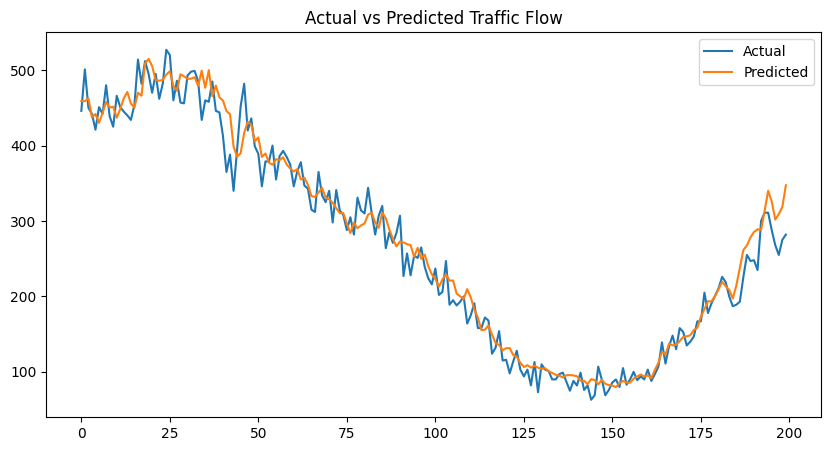

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

preds = []
actual = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)

        out = model(batch_x)

        preds.append(out.cpu().numpy())
        actual.append(batch_y.numpy())

preds = np.concatenate(preds)
actual = np.concatenate(actual)

# denormalize (IMPORTANT)
preds = preds * std + mean
actual = actual * std + mean

# metrics
mae = mean_absolute_error(actual.flatten(), preds.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(), preds.flatten()))

print("MAE:", mae)
print("RMSE:", rmse)

# plot
plt.figure(figsize=(10,5))
plt.plot(actual[:200,0,0], label="Actual")
plt.plot(preds[:200,0,0], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Traffic Flow")
plt.show()


In [24]:
pip install torchsummary

In [25]:
from torchsummary import summary